In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [6]:
!pip install pandas numpy matplotlib seaborn



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [9]:
df = pd.read_csv("../data/transactions.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/transactions.csv'

In [10]:
df = pd.read_csv("upi_fraud_detection.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'upi_fraud_detection.csv'

In [11]:
df = pd.read_csv("../data/upi_fraud_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/upi_fraud_dataset.csv'

In [18]:
df = pd.read_csv("upi_fraud_dataset.csv")

In [19]:
df.head()

,Id,trans_hour,trans_day,trans_month,trans_year,category,upi_number,age,trans_amount,state,zip,fraud_risk
0,0,0,1,1,2022,12,9957000001,54,66.21,22,49879,0
1,1,1,1,1,2022,3,9957000002,15,55.81,14,62668,0
2,2,3,1,1,2022,8,9957000003,60,8.68,4,96037,0
3,3,6,1,1,2022,4,9957000004,44,89.52,40,29911,0
4,4,6,1,1,2022,0,9957000005,72,1.90,38,16421,0


In [20]:
df.shape

(2666, 12)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2666 non-null   int64  
 1   trans_hour    2666 non-null   int64  
 2   trans_day     2666 non-null   int64  
 3   trans_month   2666 non-null   int64  
 4   trans_year    2666 non-null   int64  
 5   category      2666 non-null   int64  
 6   upi_number    2666 non-null   int64  
 7   age           2666 non-null   int64  
 8   trans_amount  2666 non-null   float64
 9   state         2666 non-null   int64  
 10  zip           2666 non-null   int64  
 11  fraud_risk    2666 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 250.1 KB


In [22]:
df.isnull().sum()

Id              0
trans_hour      0
trans_day       0
trans_month     0
trans_year      0
category        0
upi_number      0
age             0
trans_amount    0
state           0
zip             0
fraud_risk      0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:

df = df.drop_duplicates()

In [25]:
df.shape

(2666, 12)

In [26]:
df.describe()

,Id,trans_hour,trans_day,trans_month,trans_year,category,upi_number,age,trans_amount,state,zip,fraud_risk
count,2666.000000,2666.000000,2666.000000,2666.000000,2666.0,2666.000000,2.666000e+03,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,1332.501500,13.383721,13.552138,3.868717,2022.0,6.800075,8.030152e+09,46.098275,329.844299,27.153788,48219.701800,0.591898
std,769.753574,8.669769,10.316915,3.198150,0.0,3.826561,1.012387e+09,18.863370,385.964247,14.084107,26617.172444,0.491574
min,0.000000,0.000000,1.000000,1.000000,2022.0,0.000000,6.900000e+09,14.000000,1.020000,0.000000,1330.000000,0.000000
25%,666.250000,3.000000,3.000000,2.000000,2022.0,4.000000,7.086000e+09,31.000000,20.987500,15.000000,25132.750000,0.000000
50%,1332.500000,15.000000,15.000000,3.000000,2022.0,7.000000,7.662001e+09,45.000000,113.255000,29.000000,48088.000000,1.000000
75%,1998.750000,22.000000,23.000000,5.000000,2022.0,11.000000,8.876000e+09,58.000000,715.187500,38.000000,68881.000000,1.000000
max,2665.000000,23.000000,31.000000,12.000000,2022.0,13.000000,9.957000e+09,94.000000,3413.050000,50.000000,99783.000000,1.000000


In [27]:
df["Amount"].mean()

KeyError: 'Amount'

In [28]:
df.columns

Index(['Id', 'trans_hour', 'trans_day', 'trans_month', 'trans_year',
       'category', 'upi_number', 'age', 'trans_amount', 'state', 'zip',
       'fraud_risk'],
      dtype='str')

In [29]:
df.isnull().sum()

Id              0
trans_hour      0
trans_day       0
trans_month     0
trans_year      0
category        0
upi_number      0
age             0
trans_amount    0
state           0
zip             0
fraud_risk      0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df["trans_amount"].describe()

count    2666.000000
mean      329.844299
std       385.964247
min         1.020000
25%        20.987500
50%       113.255000
75%       715.187500
max      3413.050000
Name: trans_amount, dtype: float64

In [32]:
df["fraud_risk"].value_counts()

fraud_risk
1    1578
0    1088
Name: count, dtype: int64

In [33]:
df["fraud_risk"].value_counts(normalize=True) * 100

fraud_risk
1    59.189797
0    40.810203
Name: proportion, dtype: float64

In [34]:
df["trans_amount"].skew()

np.float64(1.0738416764023326)

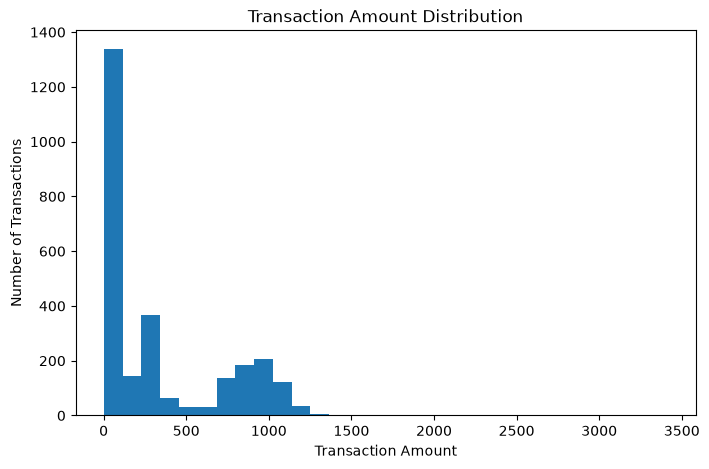

In [35]:
plt.figure(figsize=(8,5))

plt.hist(df["trans_amount"], bins=30)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")

plt.show()

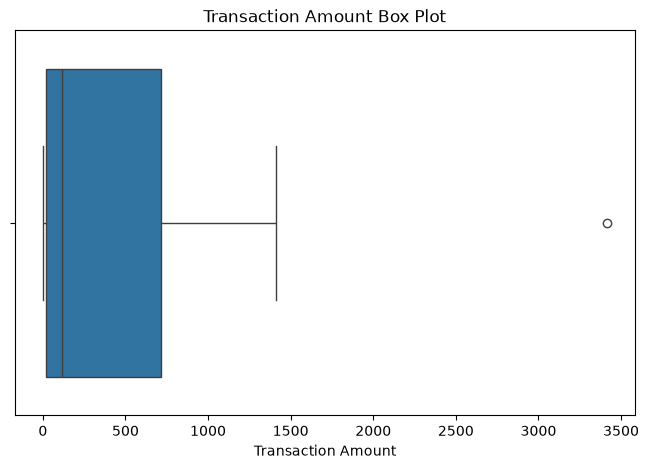

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["trans_amount"])

plt.xlabel("Transaction Amount")
plt.title("Transaction Amount Box Plot")

plt.show()

In [37]:
Q1 = df["trans_amount"].quantile(0.25)
Q3 = df["trans_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 20.9875
Q3: 715.1875
IQR: 694.2
Lower Limit: -1020.3125000000002
Upper Limit: 1756.4875000000002


In [38]:
from scipy.stats import zscore

df["amount_zscore"] = zscore(df["trans_amount"])

print(df[["trans_amount", "amount_zscore"]].head())

ModuleNotFoundError: No module named 'scipy'

In [42]:
!pip install scipy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
from scipy.stats import zscore

df["amount_zscore"] = zscore(df["trans_amount"])

print(df[["trans_amount", "amount_zscore"]].head())

   trans_amount  amount_zscore
0         66.21      -0.683182
1         55.81      -0.710132
2          8.68      -0.832265
3         89.52      -0.622776
4          1.90      -0.849835


In [44]:
zscore_outliers = df[df["amount_zscore"].abs() > 3]

print("Number of Z-score Outliers:", len(zscore_outliers))

Number of Z-score Outliers: 1


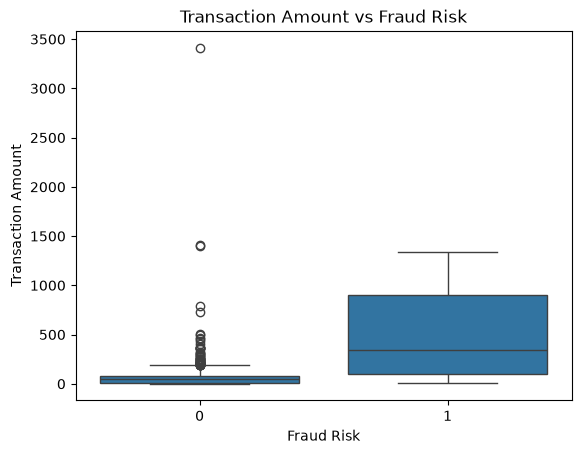

In [45]:
sns.boxplot(x="fraud_risk", y="trans_amount", data=df)

plt.xlabel("Fraud Risk")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount vs Fraud Risk")

plt.show()

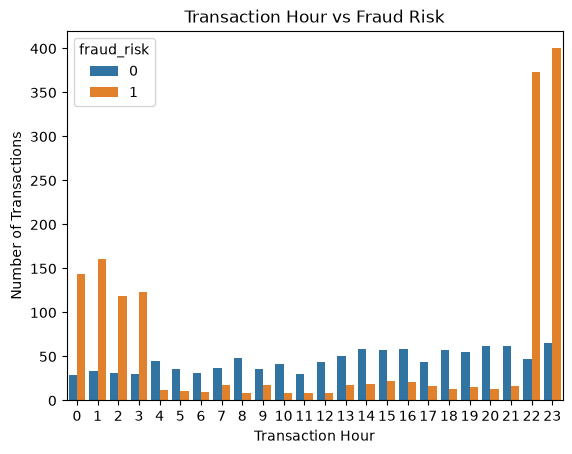

In [46]:
sns.countplot(x="trans_hour", hue="fraud_risk", data=df)

plt.xlabel("Transaction Hour")
plt.ylabel("Number of Transactions")
plt.title("Transaction Hour vs Fraud Risk")

plt.show()

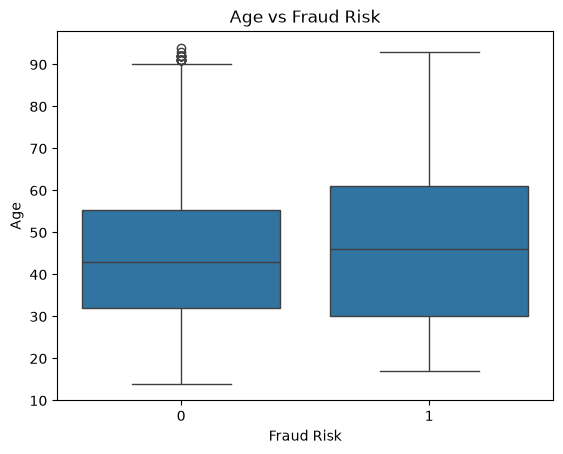

In [47]:
sns.boxplot(x="fraud_risk", y="age", data=df)

plt.xlabel("Fraud Risk")
plt.ylabel("Age")
plt.title("Age vs Fraud Risk")

plt.show()

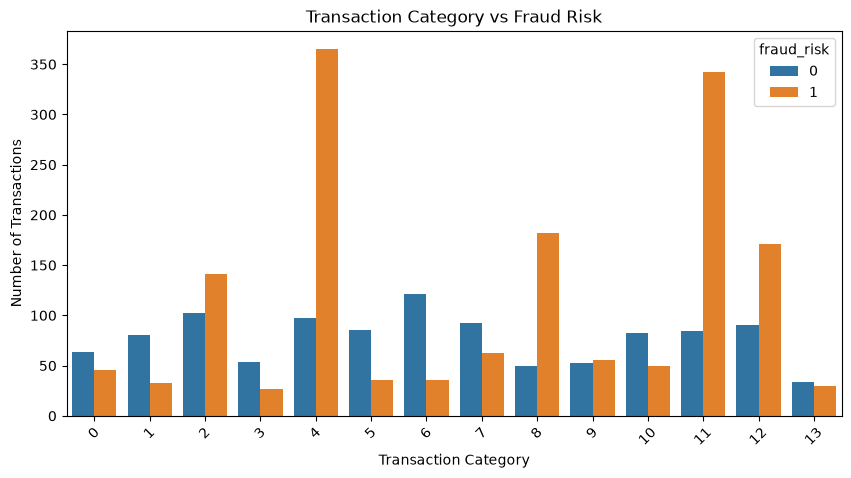

In [48]:
plt.figure(figsize=(10,5))

sns.countplot(x="category", hue="fraud_risk", data=df)

plt.xlabel("Transaction Category")
plt.ylabel("Number of Transactions")
plt.title("Transaction Category vs Fraud Risk")

plt.xticks(rotation=45)
plt.show()

In [49]:
from scipy.stats import ttest_ind

fraud_amount = df[df["fraud_risk"] == 1]["trans_amount"]
normal_amount = df[df["fraud_risk"] == 0]["trans_amount"]

t_stat, p_value = ttest_ind(fraud_amount, normal_amount)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 35.42705234663434
P-value: 1.3395252206355093e-225


In [50]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


In [51]:
category_fraud = pd.crosstab(
    df["category"],
    df["fraud_risk"],
    normalize="index"
) * 100

print(category_fraud)

fraud_risk          0          1
category                        
0           58.181818  41.818182
1           70.796460  29.203540
2           41.975309  58.024691
3           66.666667  33.333333
4           20.995671  79.004329
5           70.247934  29.752066
6           77.070064  22.929936
7           59.354839  40.645161
8           21.551724  78.448276
9           48.623853  51.376147
10          62.121212  37.878788
11          19.718310  80.281690
12          34.482759  65.517241
13          53.125000  46.875000


In [52]:
category_fraud.sort_values(
    by=1,
    ascending=False
)

fraud_risk,0,1
category,,
11,19.718310,80.281690
4,20.995671,79.004329
8,21.551724,78.448276
12,34.482759,65.517241
2,41.975309,58.024691
9,48.623853,51.376147
13,53.125000,46.875000
0,58.181818,41.818182
7,59.354839,40.645161


In [53]:
high_value = df[df["trans_amount"] > df["trans_amount"].quantile(0.95)]

print("Number of High-Value Transactions:", len(high_value))
print(high_value[["trans_amount", "trans_hour", "category", "fraud_risk"]].head(10))

Number of High-Value Transactions: 134
     trans_amount  trans_hour  category  fraud_risk
47        1092.68          23        11           1
48        1254.27          23        11           1
73        1099.99          23        11           1
88        1177.79          22        11           1
140       1127.56           3        11           1
165       1131.66          22        11           1
168       1050.01          23        11           1
186       1104.38          22        12           1
194       1148.15          23        12           1
206       1161.58          22        11           1


In [54]:
hour_fraud = pd.crosstab(
    df["trans_hour"],
    df["fraud_risk"],
    normalize="index"
) * 100

print(hour_fraud)

fraud_risk          0          1
trans_hour                      
0           16.763006  83.236994
1           17.010309  82.989691
2           20.666667  79.333333
3           19.607843  80.392157
4           78.947368  21.052632
5           76.595745  23.404255
6           75.609756  24.390244
7           67.272727  32.727273
8           85.714286  14.285714
9           66.666667  33.333333
10          82.352941  17.647059
11          76.923077  23.076923
12          83.018868  16.981132
13          73.529412  26.470588
14          75.641026  24.358974
15          72.151899  27.848101
16          73.417722  26.582278
17          72.131148  27.868852
18          81.428571  18.571429
19          78.571429  21.428571
20          82.666667  17.333333
21          79.487179  20.512821
22          11.190476  88.809524
23          13.978495  86.021505


In [55]:
signal_summary = {
    "High Value Transactions": len(high_value),
    "Late Night Transactions": len(df[df["trans_hour"].isin([0, 1, 2, 3, 4, 5])]),
    "Categories": df["category"].nunique()
}

print(signal_summary)

{'High Value Transactions': 134, 'Late Night Transactions': 774, 'Categories': 14}


In [56]:
fraud_signals = pd.DataFrame({
    "Fraud Signal": [
        "High Transaction Amount",
        "Late Night Transactions",
        "Transaction Category",
        "Transaction Hour"
    ],
    "Severity": [
        "High",
        "Medium",
        "Medium",
        "Medium"
    ],
    "Description": [
        "Unusually high transaction amounts may indicate suspicious activity.",
        "Transactions during late-night hours may require additional monitoring.",
        "Some transaction categories may show higher fraud percentages.",
        "Certain transaction hours may have higher fraud occurrence."
    ]
})
fraud_signals

,Fraud Signal,Severity,Description
0,High Transaction Amount,High,Unusually high transaction amounts may indicat...
1,Late Night Transactions,Medium,Transactions during late-night hours may requi...
2,Transaction Category,Medium,Some transaction categories may show higher fr...
3,Transaction Hour,Medium,Certain transaction hours may have higher frau...


In [57]:
print("Variables that may strongly indicate fraud:")
print("1. Transaction Amount")
print("2. Transaction Hour")
print("3. Transaction Category")
print("4. Age")

Variables that may strongly indicate fraud:
1. Transaction Amount
2. Transaction Hour
3. Transaction Category
4. Age


In [58]:
high_value_fraud = pd.crosstab(
    high_value["fraud_risk"],
    columns="Count"
)

print(high_value_fraud)

col_0       Count
fraud_risk       
0               3
1             131


In [59]:
print(high_value["fraud_risk"].value_counts(normalize=True) * 100)

fraud_risk
1    97.761194
0     2.238806
Name: proportion, dtype: float64


In [60]:
print("Suspicious Behaviours:")
print("1. Unusually high transaction amounts")
print("2. Transactions during unusual hours")
print("3. Transaction categories with higher fraud percentage")
print("4. Unusual patterns among different age groups")

Suspicious Behaviours:
1. Unusually high transaction amounts
2. Transactions during unusual hours
3. Transaction categories with higher fraud percentage
4. Unusual patterns among different age groups


In [61]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 40, 60, 100],
    labels=["18-25", "26-40", "41-60", "61+"]
)

age_fraud = pd.crosstab(
    df["age_group"],
    df["fraud_risk"],
    normalize="index"
) * 100

print(age_fraud)

fraud_risk          0          1
age_group                       
18-25       33.910891  66.089109
26-40       49.657064  50.342936
41-60       41.764081  58.235919
61+         33.108108  66.891892


In [62]:
print("Business Recommendations:")
print("1. Monitor unusually high-value transactions.")
print("2. Apply additional verification for suspicious transactions.")
print("3. Monitor transaction patterns during unusual hours.")
print("4. Monitor categories with higher fraud percentages.")
print("5. Use statistical analysis to identify unusual transaction patterns.")

Business Recommendations:
1. Monitor unusually high-value transactions.
2. Apply additional verification for suspicious transactions.
3. Monitor transaction patterns during unusual hours.
4. Monitor categories with higher fraud percentages.
5. Use statistical analysis to identify unusual transaction patterns.
